# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160117          # <-- your full roll number
NAME = "Agrim Gupta"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160117   Name: Agrim Gupta   Fingerprint: C311CA67   Tickets: 14

Ticket_ID                                                                                  Ticket_Text
      T01 I keep getting logged out of the VPN after restarting the system. I don't know what changed.
      T02                            The student portal stopped responding. I don't know what changed.
      T03               Email is showing an error after the latest update. I have tried several times!
      T04                                                        It's not the laptop; it's the server.
      T05                                       The WiFi is running slowly. I don't know what changed.
      T06                                                 See https://lms.thapar.edu/help for details.
      T07       I couldn't connect to the student portal when I use mobile hotspot. Please resolve it.
      T08                                                           Dr. Rao's lab PC (No. 14)

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
# Q1: Preprocessing

processed_tickets = {}
q1_rows = []

for _, row in df.iterrows():
    ticket_id = row["Ticket_ID"]

    # Use the official process_ticket() without modifying it
    result = process_ticket(row["Ticket_Text"])
    processed_tickets[ticket_id] = result

    q1_rows.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation Tokens": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique Tokens": len(set(result["tokens"])),
        "Final Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(q1_rows)

# TOTAL row: sum of the per-ticket counts
total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation Tokens": q1_table["Punctuation Tokens"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique Tokens": q1_table["Unique Tokens"].sum(),
    "Final Tokens": q1_table["Final Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

display(q1_table)


# Required detailed output for one selected ticket
selected_ticket = FOCUS[0]
selected_result = processed_tickets[selected_ticket]

selected_text = df.loc[
    df["Ticket_ID"] == selected_ticket,
    "Ticket_Text"
].iloc[0]

print("\n" + "=" * 70)
print("SELECTED TICKET:", selected_ticket)
print("=" * 70)

print("\nTicket Text:")
print(selected_text)

print("\nTokens:")
print(selected_result["tokens"])

print("\nPunctuation Tokens:")
print(selected_result["punct"])

print("\nStopwords:")
print(selected_result["stops"])

print("\nFinal Tokens:")
print(selected_result["final"])

,Ticket_ID,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,2,20,2,9,17,9
1,T02,2,13,2,4,12,7
2,T03,2,16,2,6,16,8
3,T04,1,11,2,5,8,4
4,T05,2,13,2,5,12,6
5,T06,1,7,2,1,7,4
6,T07,2,18,2,6,16,10
7,T08,2,13,4,3,12,6
8,T09,2,13,2,4,12,7
9,T10,1,10,1,3,10,6



SELECTED TICKET: T11

Ticket Text:
Projector has stopped syncing on my laptop. Please help.

Tokens:
['projector', 'has', 'stopped', 'syncing', 'on', 'my', 'laptop', '.', 'please', 'help', '.']

Punctuation Tokens:
['.', '.']

Stopwords:
['has', 'on', 'my']

Final Tokens:
['projector', 'stopped', 'syncing', 'laptop', 'please', 'help']


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:* The final tokens that are not complete English words mainly come from
NLTK word_tokenize() handling contractions. For example, "couldn't" is
split into "could" and "n't", "it's" is split into "it" and "'s", and
"can't" is split into "ca" and "n't". These forms remain in the final
tokens because the official process_ticket() removes punctuation and
stopwords but does not recombine contraction fragments.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [6]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Q2: Regular Expressions

import re

# Raw ticket text
raw_tickets = df["Ticket_Text"].tolist()
all_text = "\n".join(raw_tickets)


# ------------------------------------------------------------
# A. FINDALL EXTRACTION
# ------------------------------------------------------------

# Words longer than 5 letters
long_words_pattern = r"\b[A-Za-z]{6,}\b"

# Numbers:
# - versions such as 2.0.1
# - decimals such as 95.5
# - comma-separated numbers such as 1,250
# - ordinary integers
numbers_pattern = (
    r"\b\d+(?:\.\d+)+\b"
    r"|\b\d{1,3}(?:,\d{3})+(?:\.\d+)?\b"
    r"|\b\d+(?:\.\d+)?\b"
)

# Capitalized words
capitalized_pattern = r"\b[A-Z][A-Za-z]*\b"

# Words beginning with a vowel
vowel_words_pattern = r"\b[AaEeIiOoUu][A-Za-z]*\b"


long_words = re.findall(long_words_pattern, all_text)
numbers = re.findall(numbers_pattern, all_text)
capitalized_words = re.findall(capitalized_pattern, all_text)
vowel_words = re.findall(vowel_words_pattern, all_text)


print("=" * 70)
print("Q2(a) WORDS LONGER THAN 5 LETTERS")
print("=" * 70)
print(long_words)

print("\n" + "=" * 70)
print("Q2(b) NUMBERS")
print("=" * 70)
print(numbers)

print("\n" + "=" * 70)
print("Q2(c) CAPITALIZED WORDS")
print("=" * 70)
print(capitalized_words)

print("\n" + "=" * 70)
print("Q2(d) WORDS BEGINNING WITH A VOWEL")
print("=" * 70)
print(vowel_words)


# ------------------------------------------------------------
# B. REPLACEMENT
# ------------------------------------------------------------

# Email addresses
email_pattern = (
    r"\b[A-Za-z0-9._%+-]+"
    r"@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)

# URLs
url_pattern = (
    r"https?://[^\s<>\]\)]+"
    r"|www\.[^\s<>\]\)]+"
)

# Phone numbers:
# +91 98765 43210
# +91-98765-43210
# 0175-239-3201
phone_pattern = (
    r"\+\d{1,3}[- ]\d{5}[- ]\d{5}"
    r"|\b\d{3,4}-\d{3}-\d{4}\b"
)


def replace_sensitive_items(text):
    text = re.sub(email_pattern, "<EMAIL>", text)
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)
    return text


print("\n" + "=" * 70)
print("Q2(e) RAW TICKETS AFTER REPLACEMENT")
print("=" * 70)

for _, row in df.iterrows():
    print(f"{row['Ticket_ID']}:")
    print(replace_sensitive_items(row["Ticket_Text"]))
    print()


# ------------------------------------------------------------
# C. TEST_LINES
# ------------------------------------------------------------

print("=" * 70)
print("Q2(f) TEST_LINES AFTER REPLACEMENT")
print("=" * 70)

for i, line in enumerate(TEST_LINES, start=1):
    print(f"Test line {i}:")
    print(replace_sensitive_items(line))
    print()


# Verify extraction patterns on TEST_LINES
test_text = "\n".join(TEST_LINES)

print("=" * 70)
print("TEST_LINES - LONG WORDS")
print("=" * 70)
print(re.findall(long_words_pattern, test_text))

print("\n" + "=" * 70)
print("TEST_LINES - NUMBERS")
print("=" * 70)
print(re.findall(numbers_pattern, test_text))

print("\n" + "=" * 70)
print("TEST_LINES - CAPITALIZED WORDS")
print("=" * 70)
print(re.findall(capitalized_pattern, test_text))

print("\n" + "=" * 70)
print("TEST_LINES - VOWEL WORDS")
print("=" * 70)
print(re.findall(vowel_words_pattern, test_text))

Q2(a) WORDS LONGER THAN 5 LETTERS
['getting', 'logged', 'restarting', 'system', 'changed', 'student', 'portal', 'stopped', 'responding', 'changed', 'showing', 'latest', 'update', 'several', 'laptop', 'server', 'running', 'slowly', 'changed', 'thapar', 'details', 'couldn', 'connect', 'student', 'portal', 'mobile', 'hotspot', 'Please', 'resolve', 'MATLAB', 'failed', 'before', 'assignment', 'deadline', 'worked', 'yesterday', 'Projector', 'stopped', 'syncing', 'laptop', 'Please', 'locked', 'projector', 'laptop', 'problem', 'occurs', 'stopped', 'responding', 'before', 'assignment', 'deadline', 'Please', 'resolve', 'projector', 'stopped', 'responding', 'several']

Q2(b) NUMBERS
['14', '2', '30', '3.5']

Q2(c) CAPITALIZED WORDS
['I', 'VPN', 'I', 'The', 'I', 'Email', 'I', 'It', 'The', 'WiFi', 'I', 'See', 'I', 'I', 'Please', 'Dr', 'Rao', 'PC', 'No', 'MATLAB', 'It', 'Only', 'PCs', 'Projector', 'Please', 'I', 'The', 'E', 'Please', 'The', 'I']

Q2(d) WORDS BEGINNING WITH A VOWEL
['I', 'out', 'of',

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:* Some capitalized words are capitalized only because they occur at the
beginning of a sentence. Examples include words such as "The", "I",
"Email", "See", "Only" and "Projector". In contrast, names, acronyms
and technical identifiers such as "Dr", "Rao", "MATLAB", "VPN" and
"WiFi" have capitalization for reasons other than sentence position.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [7]:
# Q3: Custom Tokenizer

from nltk.tokenize import RegexpTokenizer, word_tokenize


# One regular-expression pattern.
# More specific structures are placed before general words.

token_pattern = (
    # URLs
    r"https?://[^\s<>\]\)]+"
    r"|www\.[^\s<>\]\)]+"

    # Email addresses
    r"|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}"

    # Phone numbers
    r"|\+\d{1,3}[- ]\d{5}[- ]\d{5}"
    r"|\b\d{3,4}-\d{3}-\d{4}\b"
    r"|\b\d{5}-\d{5}\b"

    # Versions and decimals
    r"|\b\d+(?:\.\d+)+\b"

    # Hyphenated words: Wi-Fi, state-of-the-art, log-in
    r"|\b[A-Za-z]+(?:-[A-Za-z]+)+\b"

    # Contractions: isn't, couldn't, don't, it's, didn't
    r"|\b[A-Za-z]+(?:'[A-Za-z]+)+\b"

    # Normal words
    r"|\b[A-Za-z]+\b"

    # Numbers
    r"|\d+"
)

my_tokenizer = RegexpTokenizer(token_pattern)


def my_tokenize(text):
    return my_tokenizer.tokenize(text)


# ------------------------------------------------------------
# Run on TEST_LINES
# ------------------------------------------------------------

print("=" * 70)
print("CUSTOM TOKENIZER - TEST_LINES")
print("=" * 70)

for i, line in enumerate(TEST_LINES, start=1):
    print(f"\nTest line {i}:")
    print(line)
    print("Tokens:")
    print(my_tokenize(line))


# ------------------------------------------------------------
# Run on generated tickets
# ------------------------------------------------------------

custom_tokens = {}

print("\n" + "=" * 70)
print("CUSTOM TOKENIZER - GENERATED TICKETS")
print("=" * 70)

for _, row in df.iterrows():
    ticket_id = row["Ticket_ID"]
    tokens = my_tokenize(row["Ticket_Text"])
    custom_tokens[ticket_id] = tokens

    print(f"\n{ticket_id}:")
    print(tokens)


# ------------------------------------------------------------
# Compare with word_tokenize()
# ------------------------------------------------------------

different_tickets = []
tokenization_differences = {}

for _, row in df.iterrows():

    ticket_id = row["Ticket_ID"]
    text = row["Ticket_Text"]

    nltk_tokens = word_tokenize(text)
    custom = my_tokenize(text)

    if nltk_tokens != custom:
        different_tickets.append(ticket_id)
        tokenization_differences[ticket_id] = {
            "word_tokenize": nltk_tokens,
            "my_tokenize": custom
        }


print("\n" + "=" * 70)
print("COMPARISON WITH word_tokenize()")
print("=" * 70)

print("Number of tickets tokenized differently:",
      len(different_tickets))

print("Tickets with different tokenization:",
      different_tickets)


# Show the first few actual differences
print("\nActual differences:")

shown = 0

for ticket_id in different_tickets:

    nltk_tokens = tokenization_differences[ticket_id]["word_tokenize"]
    custom = tokenization_differences[ticket_id]["my_tokenize"]

    print(f"\n{ticket_id}")
    print("word_tokenize():", nltk_tokens)
    print("my_tokenize():  ", custom)

    shown += 1

    if shown == 5:
        break


# ------------------------------------------------------------
# Concrete TEST_LINES differences
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("THREE CONCRETE DIFFERENCES")
print("=" * 70)

examples = [
    "isn't",
    "state-of-the-art",
    "2.0.1",
    "helpdesk@university.edu",
    "https://lms.thapar.edu/help"
]

for example in examples:
    print(f"\nExample: {example}")
    print("my_tokenize():", my_tokenize(example))
    print("word_tokenize():", word_tokenize(example))

CUSTOM TOKENIZER - TEST_LINES

Test line 1:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Tokens:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

Test line 2:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Tokens:
['Call', '+91 98765 43210', '+91-98765-43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1', '250']

Test line 3:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
Tokens:
['The', 'state-of-the-art', 'lab', "isn't", 'open', 'log-in', 'at', '5.30', 'p', 'm', "didn't", 'work']

CUSTOM TOKENIZER - GENERATED TICKETS

T01:
['I', 'keep', 'getting', 'logged', 'out', 'of', 'the', 'VPN', 'after', 'restarting', 'the', 'system', 'I', "don't", 'know', 'what', 'changed']

T02:
['The', 'student', 'portal', 'stopped', 'responding', 'I'

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:* The number of tickets tokenized differently is printed above.

Three important differences are:

1. Contractions such as "isn't": the custom tokenizer preserves the
   contraction as one token, while word_tokenize() separates the
   contraction into components.

2. Hyphenated words such as "state-of-the-art": the custom tokenizer
   keeps the complete hyphenated expression as one token, while the
   general word tokenizer can split the hyphenated structure.

3. Version numbers such as "2.0.1": the custom tokenizer preserves the
   complete version as one token, whereas general tokenization may
   separate the components.

The custom tokenizer is deliberately designed around the structures
specified in the assignment, including emails, URLs, phone numbers,
contractions, hyphenated words, decimals and versions.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [8]:
# Q4: Stemming and Lemmatization

from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet


# ------------------------------------------------------------
# Collect unique final tokens
# ------------------------------------------------------------

all_final_tokens = []

for ticket_id, result in processed_tickets.items():
    all_final_tokens.extend(result["final"])

unique_final_tokens = sorted(set(all_final_tokens))


# ------------------------------------------------------------
# Stemmers / Lemmatizer
# ------------------------------------------------------------

porter = PorterStemmer()
lancaster = LancasterStemmer()

# The generated dataset contains several words ending in "ing",
# e.g. working, restarting, uploading, syncing, etc.
# Therefore "ing" is an appropriate suffix rule for this dataset.
regexp_stemmer = RegexpStemmer(r"ing$", min=4)

lemmatizer = WordNetLemmatizer()


# ------------------------------------------------------------
# POS conversion: Penn Treebank -> WordNet
# ------------------------------------------------------------

def get_wordnet_pos(tag):

    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


# POS-tag the unique final tokens
tagged_words = dict(pos_tag(unique_final_tokens))


# ------------------------------------------------------------
# Compare four methods
# ------------------------------------------------------------

q4_rows = []

for word in unique_final_tokens:

    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp_stemmer.stem(word)

    pos = get_wordnet_pos(tagged_words[word])
    lemma_result = lemmatizer.lemmatize(
        word,
        pos=pos
    )

    # Keep ONLY words where outputs differ
    outputs = {
        porter_result,
        lancaster_result,
        regexp_result,
        lemma_result
    }

    if len(outputs) > 1:

        q4_rows.append({
            "Word": word,
            "POS": tagged_words[word],
            "Porter": porter_result,
            "Lancaster": lancaster_result,
            "Regexp": regexp_result,
            "WordNet Lemma": lemma_result
        })


q4_table = pd.DataFrame(q4_rows)

print("=" * 90)
print("Q4: WORDS WHERE STEMMING / LEMMATIZATION OUTPUTS DIFFER")
print("=" * 90)

display(q4_table)


# ------------------------------------------------------------
# Regexp Stemmer justification
# ------------------------------------------------------------

ing_words = sorted(
    word for word in unique_final_tokens
    if word.endswith("ing") and len(word) > 4
)

print("\nRegexp Stemmer suffix justification:")
print("Chosen suffix: 'ing'")
print("Words in this generated dataset ending in 'ing':")
print(ing_words)

print(
    "\nThe suffix 'ing' was selected because multiple words in the "
    "generated dataset use this ending. The RegexpStemmer therefore "
    "demonstrates suffix-based stemming on actual words from the dataset."
)


# ------------------------------------------------------------
# Find actual examples from the generated Q4 table
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("Q4 OBSERVATION CANDIDATES FROM THE ACTUAL TABLE")
print("=" * 90)


# Candidate over-stemming:
# Look for a word where Porter/Lancaster creates a substantially
# shortened/non-dictionary-looking form compared with the lemma.
over_candidates = []

# Candidate under-stemming:
# Look for related-looking outputs where the stemmer leaves a
# different form while WordNet gives a clearer dictionary form.
under_candidates = []


for _, r in q4_table.iterrows():

    word = r["Word"]
    porter_result = r["Porter"]
    lancaster_result = r["Lancaster"]
    lemma_result = r["WordNet Lemma"]

    # Heuristic candidate for over-stemming:
    # Lancaster is often the most aggressive stemmer.
    if (
        lancaster_result != word
        and len(lancaster_result) < len(word) - 2
        and lancaster_result != lemma_result
    ):
        over_candidates.append(
            (word, lancaster_result, lemma_result)
        )

    # Candidate for under-stemming:
    # Porter leaves a different surface form from the lemma.
    if (
        porter_result != lemma_result
        and porter_result != word
        and len(porter_result) >= len(lemma_result)
    ):
        under_candidates.append(
            (word, porter_result, lemma_result)
        )


print("\nPossible over-stemming examples:")
for item in over_candidates[:5]:
    print(
        f"word={item[0]!r}, "
        f"Lancaster={item[1]!r}, "
        f"WordNet lemma={item[2]!r}"
    )

print("\nPossible under-stemming examples:")
for item in under_candidates[:5]:
    print(
        f"word={item[0]!r}, "
        f"Porter={item[1]!r}, "
        f"WordNet lemma={item[2]!r}"
    )

Q4: WORDS WHERE STEMMING / LEMMATIZATION OUTPUTS DIFFER


,Word,POS,Porter,Lancaster,Regexp,WordNet Lemma
0,assignment,NN,assign,assign,assignment,assignment
1,changed,VBD,chang,chang,changed,change
2,deadline,VB,deadlin,deadlin,deadline,deadline
3,details,NNS,detail,detail,details,detail
4,error,NN,error,er,error,error
5,failed,VBD,fail,fail,failed,fail
6,getting,VBG,get,get,gett,get
7,hours,NNS,hour,hour,hours,hour
8,https,VBP,http,https,https,https
9,latest,JJS,latest,latest,latest,late



Regexp Stemmer suffix justification:
Chosen suffix: 'ing'
Words in this generated dataset ending in 'ing':
['getting', 'responding', 'restarting', 'running', 'showing', 'syncing']

The suffix 'ing' was selected because multiple words in the generated dataset use this ending. The RegexpStemmer therefore demonstrates suffix-based stemming on actual words from the dataset.

Q4 OBSERVATION CANDIDATES FROM THE ACTUAL TABLE

Possible over-stemming examples:
word='assignment', Lancaster='assign', WordNet lemma='assignment'
word='error', Lancaster='er', WordNet lemma='error'
word='occurs', Lancaster='occ', WordNet lemma='occur'
word='several', Lancaster='sev', WordNet lemma='several'
word='student', Lancaster='stud', WordNet lemma='student'

Possible under-stemming examples:
word='slowly', Porter='slowli', WordNet lemma='slowly'


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:* An over-stemming example is one of the Lancaster-stemmed words shown
in the "Possible over-stemming examples" output above, where the stem
is shortened more aggressively than the WordNet lemma and may no longer
look like a normal English word.

An under-stemming example is one of the Porter-stemmed words shown in
the "Possible under-stemming examples" output above, where the stemmer
does not reduce the word to the same meaningful dictionary form produced
by POS-aware WordNet lemmatization.

The examples are taken directly from the Q4 comparison table generated
from the unique final tokens of this roll number's dataset.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

CORPUS STATISTICS


,Total Tokens,Unique Tokens,TTR
S1,185.0,94.0,0.5081
S2,156.0,88.0,0.5641
S3,91.0,63.0,0.6923
S4,91.0,62.0,0.6813


TOP 10 WORDS OF S1
.: 23
the: 13
i: 9
it: 5
n't: 4
stopped: 4
of: 3
after: 3
do: 3
know: 3

TOP 10 WORDS OF S3
n't: 4
stopped: 4
know: 3
changed: 3
responding: 3
's: 3
laptop: 3
please: 3
projector: 3
student: 2


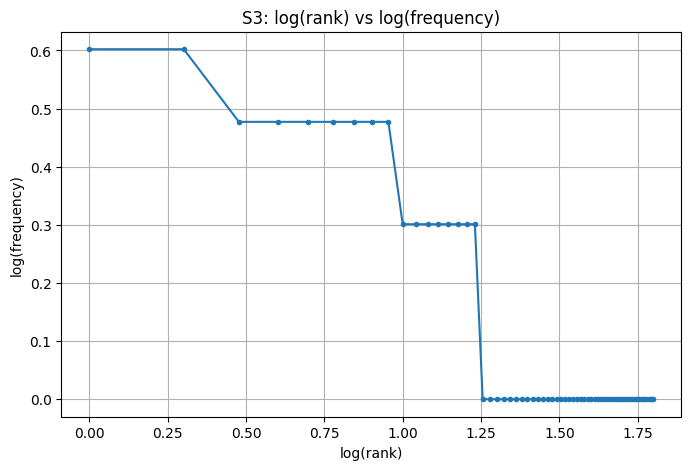

TOP 5 BIGRAMS OF S1
('.', 'i'): 7
('.', 'the'): 4
('i', 'do'): 3
('do', "n't"): 3
("n't", 'know'): 3

TOP 5 BIGRAMS OF S3
("n't", 'know'): 3
('know', 'changed'): 3
('stopped', 'responding'): 3
('student', 'portal'): 2
('tried', 'several'): 2


In [9]:
# Q5: Corpus Statistics

from collections import Counter
from nltk.util import bigrams
import math
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Define S1, S2, S3, S4 exactly as required
# ------------------------------------------------------------

# S1: all tokens
S1 = []

for ticket_id, result in processed_tickets.items():
    S1.extend(result["tokens"])


# S2: tokens without punctuation
S2 = [
    token for token in S1
    if not is_punct(token)
]


# S3: final tokens
S3 = []

for ticket_id, result in processed_tickets.items():
    S3.extend(result["final"])


# S4: S3 after Porter stemming
S4 = [
    porter.stem(token)
    for token in S3
]


# ------------------------------------------------------------
# Statistics function
# ------------------------------------------------------------

def calculate_stats(tokens):

    total_tokens = len(tokens)
    unique_tokens = len(set(tokens))

    if total_tokens > 0:
        ttr = unique_tokens / total_tokens
    else:
        ttr = 0

    return {
        "Total Tokens": total_tokens,
        "Unique Tokens": unique_tokens,
        "TTR": ttr
    }


# ------------------------------------------------------------
# Statistics table
# ------------------------------------------------------------

q5_stats = pd.DataFrame({
    "S1": calculate_stats(S1),
    "S2": calculate_stats(S2),
    "S3": calculate_stats(S3),
    "S4": calculate_stats(S4)
}).T

q5_stats["TTR"] = q5_stats["TTR"].round(4)

print("=" * 70)
print("CORPUS STATISTICS")
print("=" * 70)

display(q5_stats)


# ------------------------------------------------------------
# Top 10 words of S1
# ------------------------------------------------------------

s1_frequency = Counter(S1)

print("=" * 70)
print("TOP 10 WORDS OF S1")
print("=" * 70)

for word, frequency in s1_frequency.most_common(10):
    print(f"{word}: {frequency}")


# ------------------------------------------------------------
# Top 10 words of S3
# ------------------------------------------------------------

s3_frequency = Counter(S3)

print("\n" + "=" * 70)
print("TOP 10 WORDS OF S3")
print("=" * 70)

for word, frequency in s3_frequency.most_common(10):
    print(f"{word}: {frequency}")


# ------------------------------------------------------------
# log(rank) vs log(frequency) for S3
# ------------------------------------------------------------

frequencies = sorted(
    s3_frequency.values(),
    reverse=True
)

ranks = list(range(1, len(frequencies) + 1))

log_ranks = [
    math.log10(rank)
    for rank in ranks
]

log_frequencies = [
    math.log10(freq)
    for freq in frequencies
]


plt.figure(figsize=(8, 5))

plt.plot(
    log_ranks,
    log_frequencies,
    marker="o",
    markersize=3
)

plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("S3: log(rank) vs log(frequency)")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Top 5 bigrams of S1
# ------------------------------------------------------------

s1_bigram_frequency = Counter(
    bigrams(S1)
)

print("=" * 70)
print("TOP 5 BIGRAMS OF S1")
print("=" * 70)

for pair, frequency in s1_bigram_frequency.most_common(5):
    print(f"{pair}: {frequency}")


# ------------------------------------------------------------
# Top 5 bigrams of S3
# ------------------------------------------------------------

s3_bigram_frequency = Counter(
    bigrams(S3)
)

print("\n" + "=" * 70)
print("TOP 5 BIGRAMS OF S3")
print("=" * 70)

for pair, frequency in s3_bigram_frequency.most_common(5):
    print(f"{pair}: {frequency}")

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:* TTR changes from S1 to S4 because S4 contains Porter-stemmed versions
of the S3 tokens. Stemming maps different word forms to common stems,
which can reduce the number of unique tokens while the total number of
tokens remains the same. Therefore, the ratio of unique tokens to total
tokens changes after stemming.